# 🏥 Healthcare Data Analysis

This notebook analyzes a healthcare dataset to uncover trends, identify patterns, and generate insights that support data-driven decision-making.

---
## 📦 Import Libraries & Load Dataset

Import the required Python libraries and load the dataset into a Pandas DataFrame for analysis.

In [219]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import math 
import matplotlib.ticker as ticker

data = pd.read_csv("healthcare_dataset.csv")


## 👀 Preview the Dataset

Display the first five rows to understand the dataset's structure, features, and sample records before analysis.

In [220]:
data = pd.read_csv("healthcare_dataset.csv")
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 🔍 Check for Missing Values

Identify missing values in each column to ensure the dataset is complete and ready for reliable analysis.

In [221]:
data = pd.read_csv("healthcare_dataset.csv")
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## 📋 Dataset Information

Examine the dataset's structure, data types, and non-null values to understand its quality and prepare it for analysis.

In [222]:
data = pd.read_csv("healthcare_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 12.3 MB


## 🧹 Check for Duplicate Records

Identify duplicate entries to maintain data quality and ensure accurate analysis results.

In [223]:
data = pd.read_csv("healthcare_dataset.csv")
data.duplicated().sum()

np.int64(534)

## ✨ Remove Duplicate Records

Remove duplicate entries to create a clean dataset for accurate and consistent analysis.

In [224]:
data = pd.read_csv("healthcare_dataset.csv")
Data = data.drop_duplicates()

## 📊 Statistical Summary

Generate summary statistics for numerical features to understand their distribution, central tendency, and variability.

In [225]:
Data.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


In [226]:
Data.describe(include=object)

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\2727778795.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Data.describe(include=object)


,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27496,6898,9218,50,27,44,11139,18473,53,11038,18437


## 🩺 Count Patients by Medical Condition

Calculate the number of patients in each medical condition category to understand the distribution of diseases in the dataset.

In [227]:

patient_count = Data["Medical Condition"].value_counts()


## 📅 Calculate Length of Stay

Convert admission and discharge dates into datetime format and calculate each patient's hospital stay in days for further analysis.

In [228]:
Data["Date of Admission"] = pd.to_datetime(Data["Date of Admission"])
Data["Discharge Date"] = pd.to_datetime(Data["Discharge Date"])

Data["length of stay"] = (Data["Discharge Date"] - Data["Date of Admission"]).dt.days

## 💰 Total Billing by Medical Condition

Calculate the total billing amount for each medical condition to identify the conditions with the highest healthcare costs.

In [229]:
total_billing = Data.groupby("Medical Condition")["Billing Amount"].sum().sort_values(ascending=False)
print(total_billing)


Medical Condition
Diabetes        2.364870e+08
Obesity         2.360067e+08
Arthritis       2.351676e+08
Hypertension    2.333785e+08
Asthma          2.331363e+08
Cancer          2.298922e+08
Name: Billing Amount, dtype: float64


## 📌 Project KPIs

This section provides a quick overview of the dataset using key performance indicators (KPIs) before detailed analysis.

In [230]:
total_patients = len(Data)
total_revenue = Data["Billing Amount"].sum()
avg_bill = Data["Billing Amount"].mean()
avg_age = Data["Age"].mean()
avg_stay = Data["length of stay"].mean()

top_condition = Data["Medical Condition"].mode()[0]
top_hospital = (
    Data.groupby("Hospital")["Billing Amount"]
    .sum()
    .idxmax()
)

print(f"Total Patients        : {total_patients:,}")
print(f"Total Revenue         : ${total_revenue:,.2f}")
print(f"Average Billing       : ${avg_bill:,.2f}")
print(f"Average Age           : {avg_age:.1f} years")
print(f"Average Length of Stay: {avg_stay:.1f} days")
print(f"Most Common Condition : {top_condition}")
print(f"Top Revenue Hospital  : {top_hospital}")

Total Patients        : 54,966
Total Revenue         : $1,404,068,339.23
Average Billing       : $25,544.31
Average Age           : 51.5 years
Average Length of Stay: 15.5 days
Most Common Condition : Arthritis
Top Revenue Hospital  : Johnson PLC


## 📊 Total Billing by Medical Condition

Visualize the total billing amount across medical conditions to compare healthcare costs and identify the highest-cost conditions.

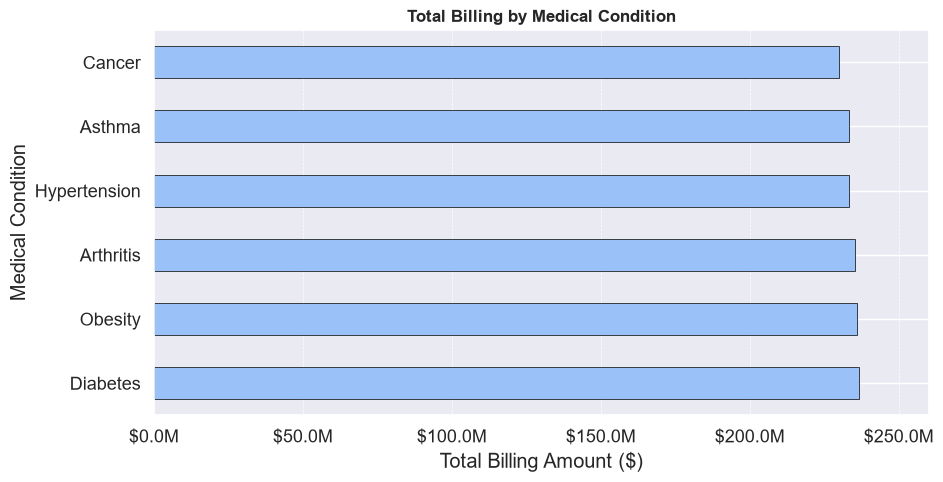

In [231]:
total_billing.plot(
    kind="barh",
    figsize=(10,5),
    edgecolor = "black",
    linewidth = 0.5,
    color = "#9BC2F8"
)

plt.title("Total Billing by Medical Condition",fontsize=12, fontweight="bold")
plt.xlabel("Total Billing Amount ($)")
plt.ylabel("Medical Condition")
plt.grid(axis= "x",linewidth = 0.5 , linestyle = "--")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"${x*1e-6:.1f}M")
)

plt.xlim(0, total_billing.max() * 1.1)


plt.show()

## 📊 Patient Distribution by Medical Condition

Visualize the number of patients across different medical conditions to identify the most common conditions in the dataset.

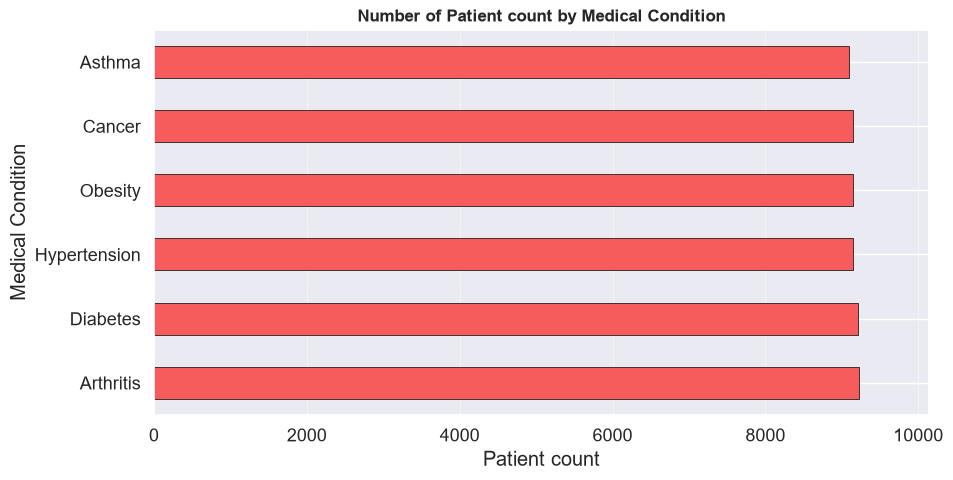

In [232]:
patient_count.plot(
    kind="barh",
    figsize = (10,5),
    edgecolor = "black",
    linewidth = 0.5,
    color = "#F65C5CFF"
)
plt.title("Number of Patient count by Medical Condition",fontsize=12, fontweight="bold")
plt.xlabel("Patient count")
plt.ylabel("Medical Condition")
plt.grid(axis="x" , linestyle = "--" , linewidth = 0.5)

plt.xlim(0,patient_count.max()*1.1)

plt.show()

## 👥 Create Age Groups

Group patients into age categories to analyze the distribution of different age groups and support demographic insights.

In [233]:
bins = [0,18,30,45,60,100]
labels = ["0-18" , "19-30", "31-45" , "46-60" , "60+"]

Data["Age group"] = pd.cut(
    Data["Age"],bins=bins , labels=labels
)

age_group = Data["Age group"].value_counts().sort_index(ascending=False)
 

## 📊 Hospital Visits by Age Group

Visualize the distribution of patients across age groups to identify the age categories with the highest number of hospital visits.

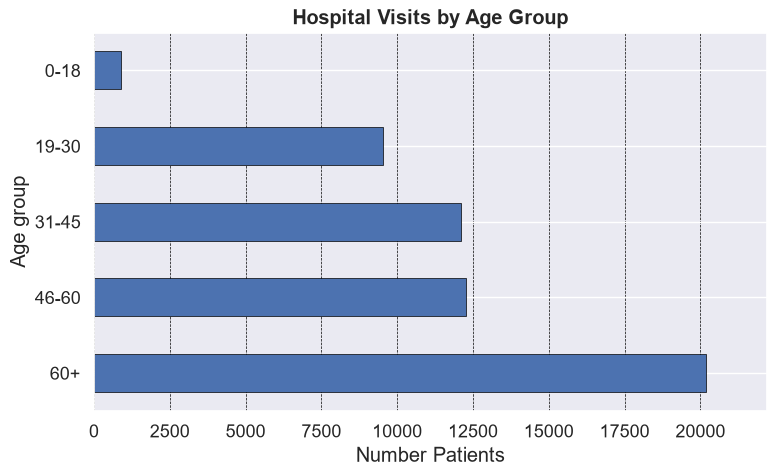

In [234]:
age_group.plot(
    kind="barh",
    figsize=(8,5),
    edgecolor="black",
    linewidth=0.5
)

plt.title("Hospital Visits by Age Group" , fontweight="bold")
plt.xlabel("Number Patients")
plt.grid(axis = "x" , linewidth = 0.5 , linestyle = "--" , color="black")
plt.xlim(0,age_group.max()*1.1)
plt.tight_layout()
plt.show()

## 💳 Billing Amount by Gender

Calculate the total billing amount by gender to compare healthcare expenses across patient groups.

In [235]:
gender_bill = Data.groupby("Gender")["Billing Amount"].sum().sort_index(ascending=False)

## 🥧 Billing Distribution by Gender

Visualize the share of total billing by gender to compare the overall contribution of each patient group to healthcare costs.

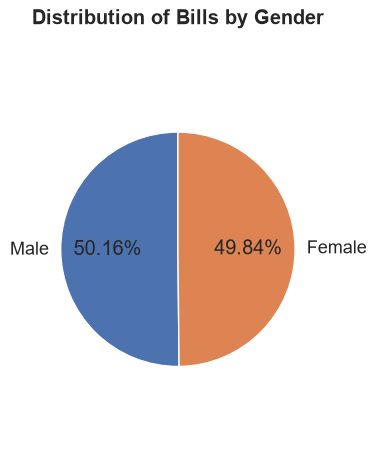

In [236]:
gender_bill.plot(
    kind="pie",
    autopct = "%1.2f%%",
    figsize=(4,5),
    startangle = 90
)
plt.title("Distribution of Bills by Gender", fontweight = "bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

## 👨‍⚕️ Top 10 Doctors by Patient Count

Identify the top 10 doctors with the highest number of patient records to understand patient distribution among healthcare providers.

In [237]:
doctor = Data["Doctor"].value_counts().head(10)
print(doctor)

Doctor
Michael Smith       27
John Smith          22
Robert Smith        21
James Smith         20
Michael Johnson     20
Robert Johnson      19
David Smith         19
Michael Williams    18
Matthew Smith       17
John Johnson        17
Name: count, dtype: int64


## 🥧 Top 10 Doctors by Patient Count

Visualize the patient share of the top 10 doctors to identify those handling the highest number of patients.

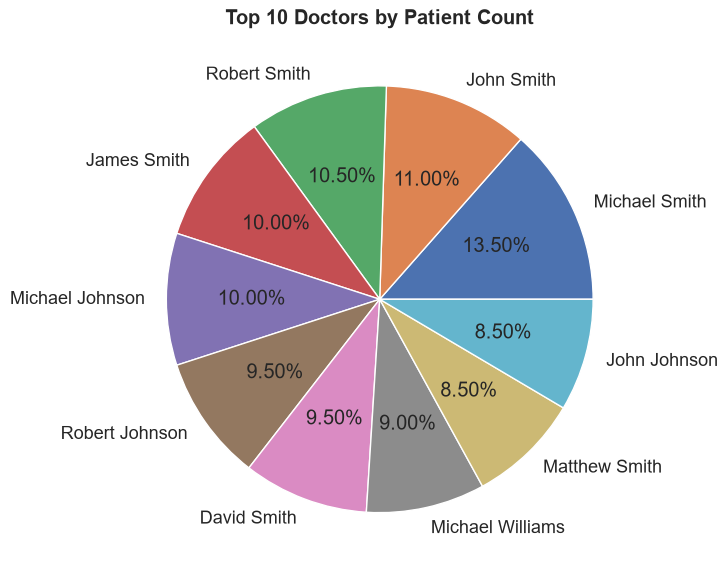

In [238]:
doctor.plot(
    kind = "pie",
    figsize=(10,6),
    autopct ="%1.2f%%"
)
plt.title("Top 10 Doctors by Patient Count" , fontweight = "bold")
plt.tight_layout()
plt.show()

## 🏥 Top 10 Hospitals by Total Billing

Calculate the total billing amount for each hospital and identify the top 10 hospitals with the highest healthcare revenue.

In [239]:
hospital = Data.groupby("Hospital")["Billing Amount"].sum().sort_values(ascending=False).head(10)
print(hospital)

Hospital
Johnson PLC    1.081477e+06
LLC Smith      1.030190e+06
Smith PLC      1.029424e+06
Ltd Smith      1.003366e+06
Smith Ltd      9.700359e+05
Johnson Inc    9.343107e+05
Group Smith    9.029758e+05
Inc Brown      8.779613e+05
LLC Johnson    8.164384e+05
Smith Group    8.066313e+05
Name: Billing Amount, dtype: float64


## 🥧 Top 10 Hospitals by Total Billing

Visualize the billing contribution of the top 10 hospitals to identify the highest revenue-generating healthcare providers.

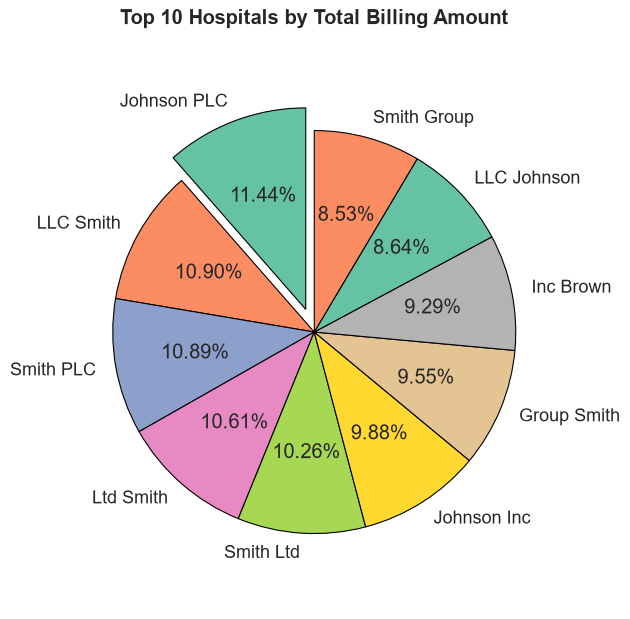

In [240]:

sns.set(font_scale=1.2)
plt.figure(figsize=(6.5, 6.5))

plt.pie(
    x=hospital.values,
    labels=hospital.index,
    autopct="%1.2f%%",
    colors=sns.color_palette("Set2", len(hospital)),
    startangle=90,
    explode=[0.12] + [0] * (len(hospital) - 1),
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}
)

plt.title("Top 10 Hospitals by Total Billing Amount", fontweight="bold")
plt.axis("equal")  # Makes the pie chart a perfect circle

plt.tight_layout()
plt.show()

## 🥧 Admission Type Distribution

Visualize the distribution of admission types to understand the proportion of emergency, urgent, and elective hospital admissions.

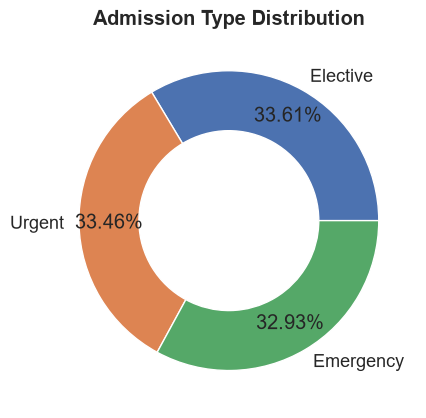

In [241]:
admission = Data["Admission Type"].value_counts()

plt.figure(figsize=(4.5, 4.5))

plt.pie(
    admission,
    labels=admission.index,
    autopct="%1.2f%%",
    pctdistance=0.8, 
    wedgeprops=dict(width=0.4),
)

plt.title("Admission Type Distribution" , fontweight = "bold")
plt.tight_layout()
plt.show()

## 🩸 Blood Type Distribution

Visualize the distribution of blood types to identify the most common and least common blood groups among patients.

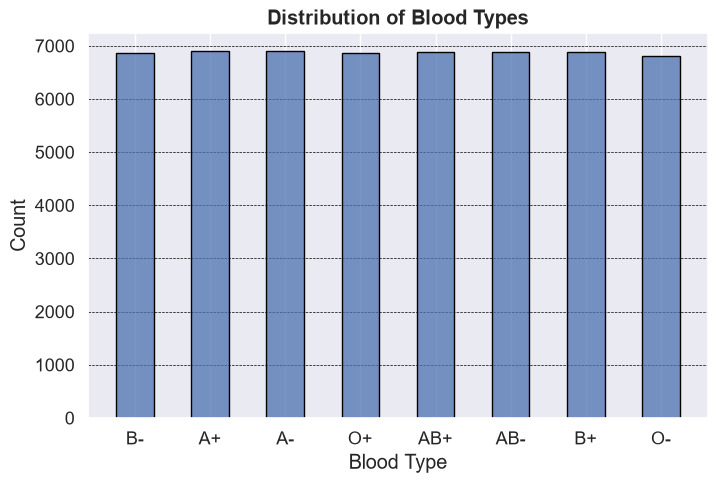

In [242]:
blood = Data["Blood Type"].value_counts()

plt.figure(figsize=(8, 5))

sns.histplot(data=Data, x="Blood Type", shrink=0.5, edgecolor="black")

plt.title("Distribution of Blood Types" , fontweight="bold")
plt.xlabel("Blood Type")
plt.ylabel("Count")
plt.grid(axis="y" , linestyle="--" , linewidth=0.5 , color="black")
plt.show()

## 📈 Distribution of Patient Length of Stay

Visualize the distribution of hospital stay duration to understand how long patients typically remain admitted.

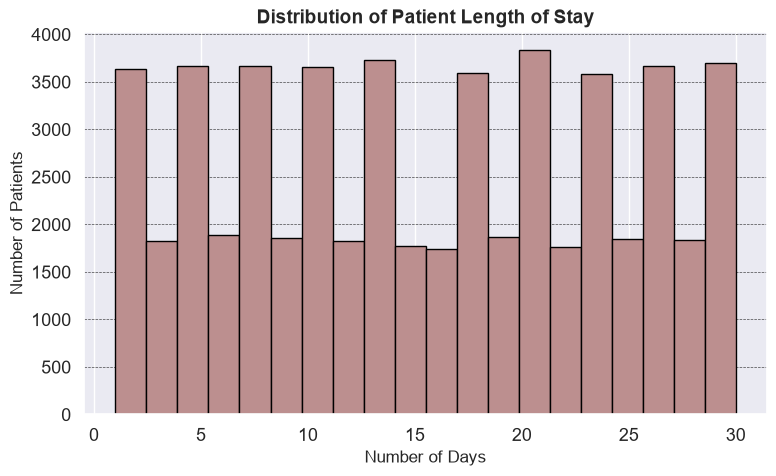

In [243]:
plt.figure(figsize=(8,5))
plt.hist(Data["length of stay"],
         bins=20,
         edgecolor="black",
         color="rosybrown")
plt.title("Distribution of Patient Length of Stay" , fontsize=14 , fontweight="bold")
plt.xlabel("Number of Days" , fontsize=12)
plt.ylabel("Number of Patients" , fontsize=12)
plt.grid(axis="y" , linestyle ="--" , alpha=0.7 , linewidth=0.5 , color="black")
plt.tight_layout()
plt.show()

## 📦 Billing Amount Distribution

Analyze the distribution of patient billing amounts and identify the presence of outliers in healthcare costs.

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\425264993.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


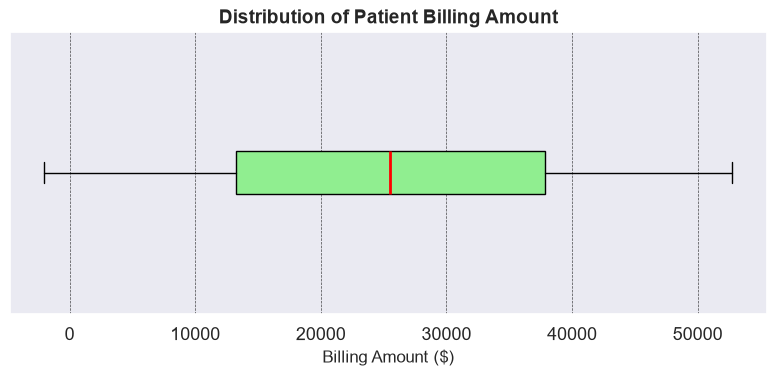

In [244]:

plt.figure(figsize=(8, 4))

plt.boxplot(
    Data["Billing Amount"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen", color="black"),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="orange", alpha=0.7)
)

plt.title("Distribution of Patient Billing Amount", fontsize=14, fontweight="bold")
plt.xlabel("Billing Amount ($)", fontsize=12)

plt.yticks([])

plt.grid(axis="x", linestyle="--", alpha=0.7 , color = "black" , linewidth = 0.5)

plt.tight_layout()  
plt.show()

## 📅 Extract Admission Month

Extract the month from the admission date to analyze monthly patient admission trends.

In [245]:
Data["Date of Admission"] = pd.to_datetime(Data["Date of Admission"])

Data["Month"] = Data["Date of Admission"].dt.month_name()

## 📊 Monthly Billing Analysis

Calculate the total billing amount by month to identify seasonal trends and monthly variations in healthcare revenue.

In [246]:
month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
Data["Month"] = pd.Categorical(Data["Month"], categories=month_order, ordered=True)

billing = Data.groupby("Month")["Billing Amount"].sum()
print(billing)

Month
January      1.197217e+08
February     1.067002e+08
March        1.173555e+08
April        1.136078e+08
May          1.153036e+08
June         1.204837e+08
July         1.214266e+08
August       1.215802e+08
September    1.138440e+08
October      1.200226e+08
November     1.159813e+08
December     1.180410e+08
Name: Billing Amount, dtype: float64


## 📈 Monthly Billing Trend

Visualize the monthly billing trend to identify revenue patterns and seasonal variations throughout the year.

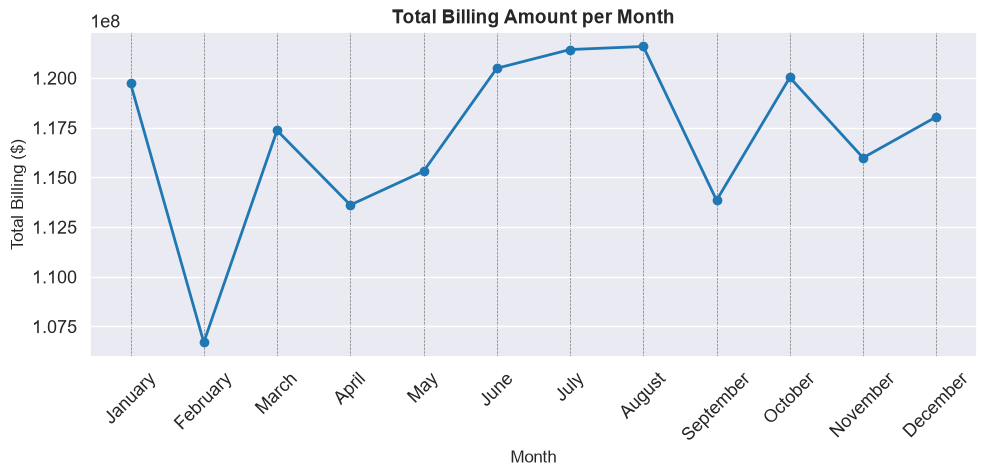

In [247]:
plt.figure(figsize=(10, 5))

billing.plot(
    kind="line",
    marker="o",                
    linewidth=2,
    color="#1f77b4"         
)

plt.title("Total Billing Amount per Month", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Billing ($)", fontsize=12)

plt.xticks(
    ticks=range(len(billing)),
    labels=billing.index,
    rotation=45
)
plt.grid(axis="x", linestyle="--", alpha=0.5 , color="black" , linewidth=0.5)

plt.tight_layout()
plt.show()

## 🔗 Length of Stay vs Billing Amount

Analyze the relationship between patient length of stay and billing amount to identify patterns between hospitalization duration and healthcare costs.

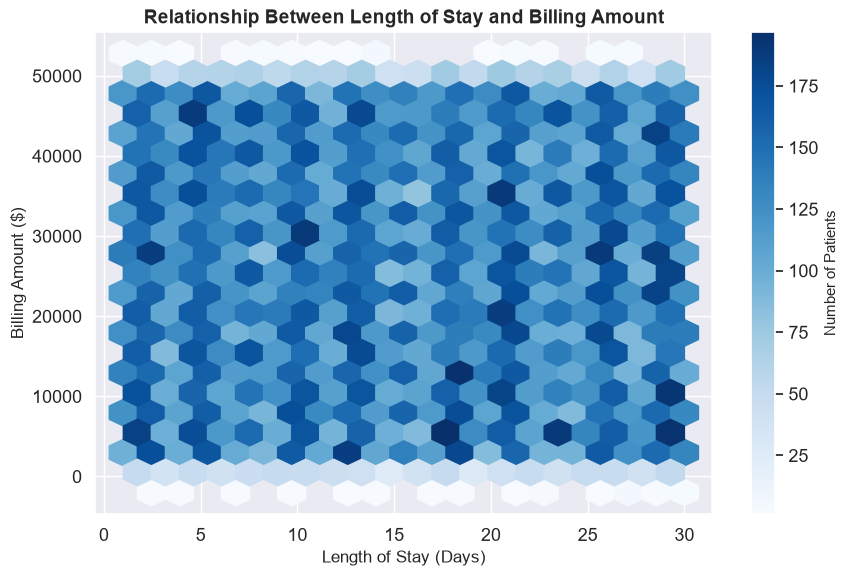

In [248]:
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    Data["length of stay"],
    Data["Billing Amount"],
    gridsize=20,           
    cmap="Blues",          
    mincnt=1               
)

cb = plt.colorbar(hb)
cb.set_label("Number of Patients", fontsize=11)

plt.title("Relationship Between Length of Stay and Billing Amount", fontsize=14, fontweight="bold")
plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Billing Amount ($)", fontsize=12)

plt.tight_layout()
plt.show()

## 💳 Billing by Insurance Provider

Compare total billing across insurance providers to identify the highest healthcare expenditures.

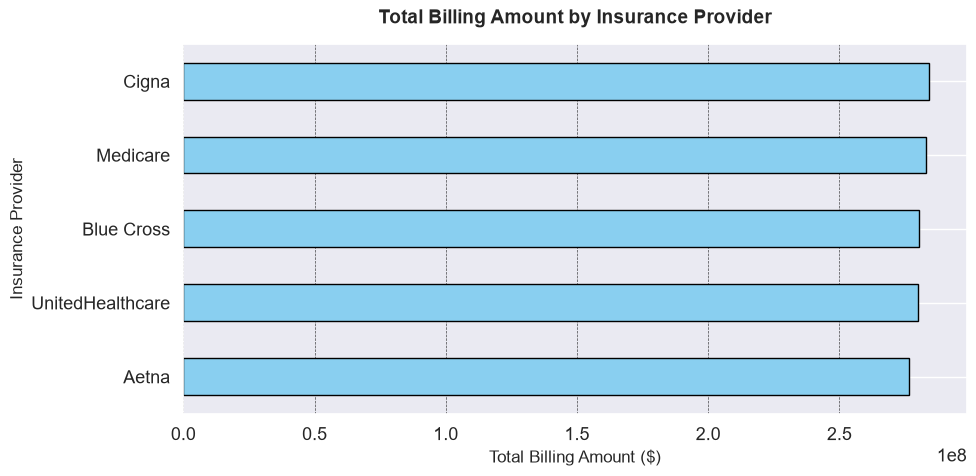

In [249]:
insurance = (
    Data.groupby("Insurance Provider")["Billing Amount"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))


insurance.plot(
    kind="barh",          
    edgecolor="black",
    color="#89CFF0"       
)

plt.title("Total Billing Amount by Insurance Provider", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Billing Amount ($)", fontsize=12)
plt.ylabel("Insurance Provider", fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7 , color = "black")

plt.tight_layout()
plt.show()

## 🧪 Test Result Distribution

Analyze patient test outcomes to understand the overall distribution of medical test results.

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\471202452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


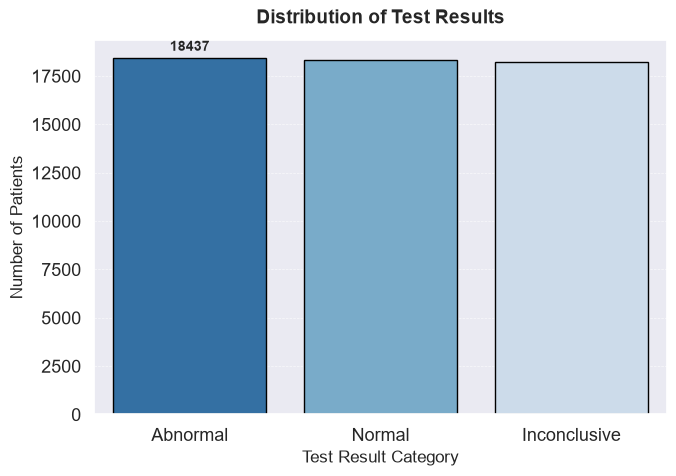

In [250]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=Data,
    x="Test Results",
    order=Data["Test Results"].value_counts().index,  
    palette="Blues_r",                                 
    edgecolor="black"
)
ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight="bold")

plt.title("Distribution of Test Results", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Test Result Category", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

## 🚑 Billing by Admission Type

Compare total billing across admission types to understand their financial impact.

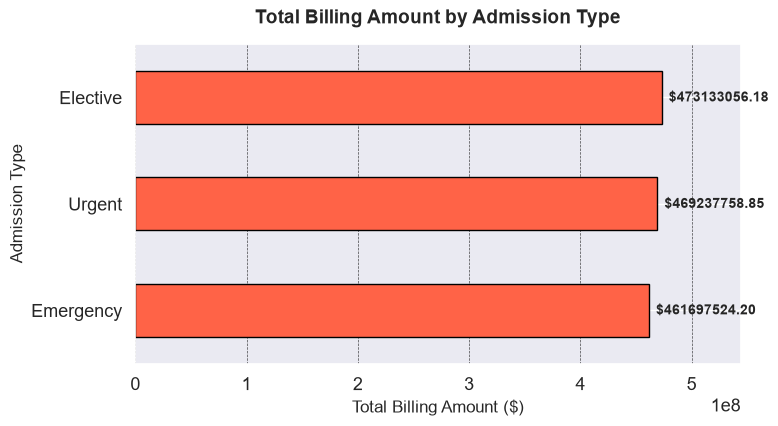

In [251]:

billing_admission = (
    Data.groupby("Admission Type")["Billing Amount"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

ax = billing_admission.plot(
    kind="barh",
    edgecolor="black",
    color="tomato"
)

ax.bar_label(
    ax.containers[0], 
    fmt="$%.2f",         
    padding=5, 
    fontsize=10, 
    fontweight="bold"
)
plt.title("Total Billing Amount by Admission Type", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Billing Amount ($)", fontsize=12)
plt.ylabel("Admission Type", fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7 , color="black")
plt.xlim(0, billing_admission.max() * 1.15)  

plt.tight_layout()
plt.show()

## 🏥 Length of Stay by Medical Condition

Compare hospital stay duration across medical conditions to identify conditions associated with longer admissions.

C:\Users\gunas\AppData\Local\Temp\ipykernel_19084\2997892950.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


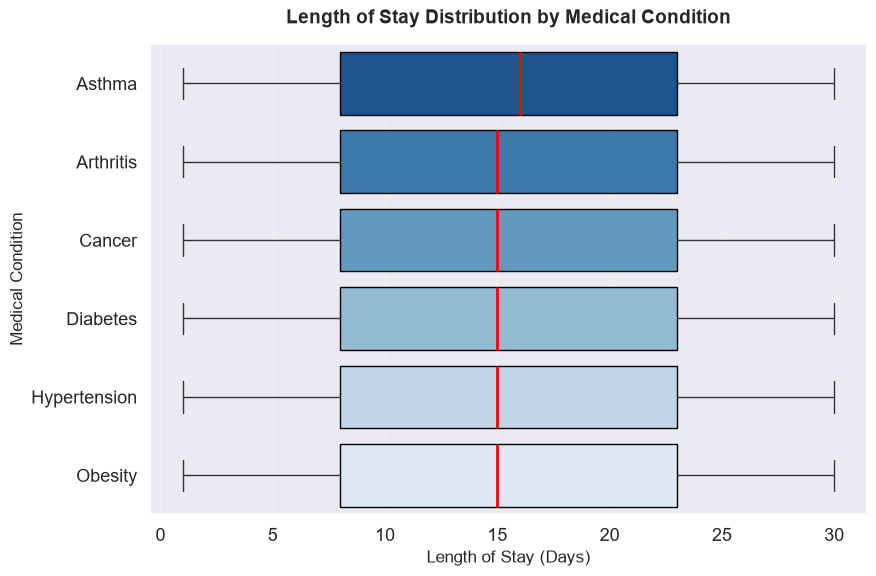

In [252]:
plt.figure(figsize=(9, 6))

order = (
    Data.groupby("Medical Condition")["length of stay"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=Data,
    y="Medical Condition",   
    x="length of stay",       
    order=order,             
    palette="Blues_r",        
    boxprops=dict(edgecolor="black"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Length of Stay Distribution by Medical Condition", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Medical Condition", fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

## 💊 Most Prescribed Medications

Identify the most frequently prescribed medications to understand treatment patterns.

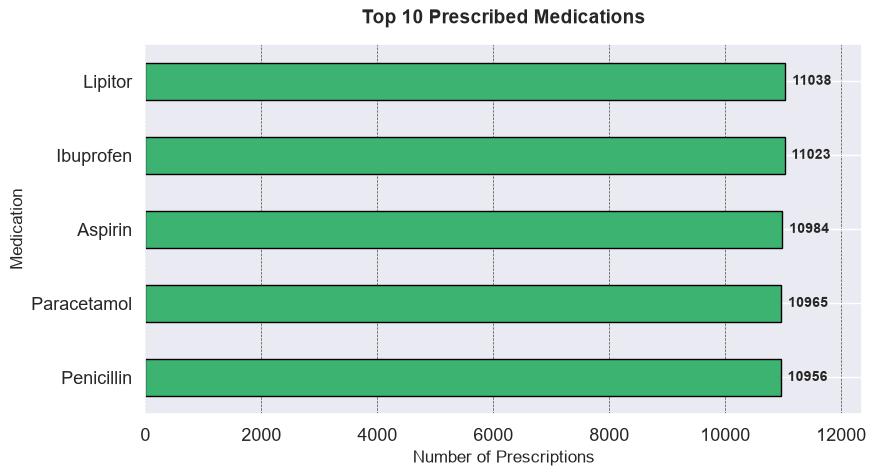

In [253]:
medicine = (
    Data["Medication"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)
plt.figure(figsize=(9, 5))

ax = medicine.plot(
    kind="barh",
    color="mediumseagreen",
    edgecolor="black"
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=10,
    fontweight="bold"
)
plt.title("Top 10 Prescribed Medications", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Prescriptions", fontsize=12)
plt.ylabel("Medication", fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7 , color ="black")
plt.xlim(0, medicine.max() * 1.12)

plt.tight_layout()
plt.show()

## 🛡️ Patient Distribution by Insurance Provider

Analyze the number of patients covered by each insurance provider.

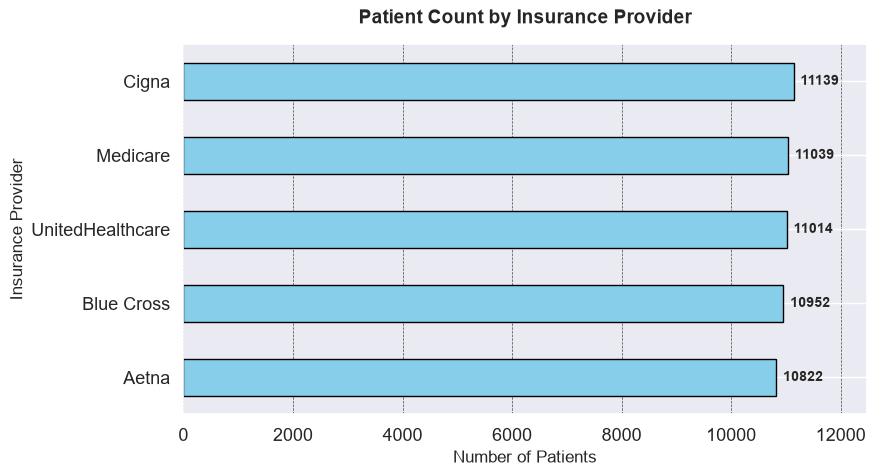

In [254]:
insurance_patients = (
    Data["Insurance Provider"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

ax = insurance_patients.plot(
    kind="barh",
    color="skyblue",
    edgecolor="black"
)
ax.bar_label(
    ax.containers[0], 
    padding=5, 
    fontsize=10, 
    fontweight="bold"
)

plt.title("Patient Count by Insurance Provider", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Patients", fontsize=12)
plt.ylabel("Insurance Provider", fontsize=12)

plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7,color="black")
plt.xlim(0, insurance_patients.max() * 1.12) 

plt.tight_layout()
plt.show()

# 📌 Key Insights

- Medical conditions such as **Diabetes, Arthritis, and Obesity** account for a significant share of patient admissions and healthcare costs.
- Patient billing varies across **medical conditions, hospitals, insurance providers, and admission types**, highlighting differences in resource utilization.
- Most patients have a **short to moderate hospital stay**, while a small number of cases result in extended admissions and higher costs.
- Monthly billing trends show fluctuations in healthcare revenue, indicating potential seasonal patterns in patient admissions.
- Patient demographics, including **age groups, gender, and blood types**, provide valuable insights for understanding the patient population.
- Correlation analysis suggests that **longer hospital stays are generally associated with higher billing amounts**, supporting the relationship between treatment duration and healthcare costs.

# ✅ Conclusion

This project demonstrates an end-to-end exploratory data analysis (EDA) of a healthcare dataset using **Python, Pandas, NumPy, Matplotlib, and Seaborn**. The analysis involved data cleaning, feature engineering, statistical exploration, and visualization to uncover meaningful patterns in patient demographics, hospital operations, and billing data.

The insights generated from this analysis can support healthcare organizations in monitoring patient trends, optimizing resource allocation, and making data-driven operational and financial decisions. This project also showcases practical data analysis skills, including data preprocessing, visualization, and business-oriented insight generation.

# 🛠️ Tools & Technologies

- **Programming Language:** Python
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn
- **Environment:** Jupyter Notebook
- **Techniques:** Data Cleaning, Feature Engineering, Exploratory Data Analysis (EDA), Data Visualization, Business Insight Generation